# DD2424 - Assignment 2
This is the main notebook containing the second assignment of course DD2424.

Note that the dataset is loaded from folder in assignment1!

In [1]:
# needed imports
import matplotlib.pyplot as plt
import numpy as np

from model import Model
from nodes import CrossEntropyLoss
from optimizer import Optimizer
from scaler import Scaler
from utils import load_batch, calculate_mean_grad_difference
from torch_gradient_computations import ComputeGradsWithTorch


## 1. Test gradient computation

In [2]:
X, Y, y = load_batch("data_batch_1")
scaler = Scaler()
X_train = scaler.fit_transform(X)

/home/josef/Uni/P4/deep_learning/DD2424-assignments/assignment2/src/utils.py:20: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  dict = pickle.load(fo, encoding='bytes')


In [3]:
model = Model(32*32*3, 100, 10)
loss_node = CrossEntropyLoss()

Y_pred = model.forward(X_train[:,:100])
loss = loss_node.forward(Y_pred, Y[:, :100])
print(f"loss computed {loss}")

loss computed 3.1049067420443452


In [4]:
# calculate my gradient
grad = loss_node.backward()
print(grad.shape)
model.backward(grad)

# calculate torch gradient
grads_torch = ComputeGradsWithTorch(X_train[:, :100], y[:100], model.layers[0].W, model.layers[0].b, model.layers[2].W, model.layers[2].b)

(10, 100)
Loss computed with PyTorch: 3.104906742044


In [5]:
print(model.layers[2].grad_b)

[[-0.0304274 ]
 [-0.08518595]
 [ 0.01107502]
 [ 0.00499653]
 [-0.06670064]
 [-0.02543581]
 [ 0.00066563]
 [-0.03376153]
 [ 0.27279882]
 [-0.04802467]]


In [6]:
print(grads_torch["b2"])

[[-0.0304274 ]
 [-0.08518595]
 [ 0.01107502]
 [ 0.00499653]
 [-0.06670064]
 [-0.02543581]
 [ 0.00066563]
 [-0.03376153]
 [ 0.27279882]
 [-0.04802467]]


In [7]:
# compare the gradients
W1_diff = calculate_mean_grad_difference(model.layers[0].grad_W.flatten(), grads_torch["W1"].flatten())
W2_diff = calculate_mean_grad_difference(model.layers[2].grad_W.flatten(), grads_torch["W2"].flatten())
b1_diff = calculate_mean_grad_difference(model.layers[0].grad_b.flatten(), grads_torch["b1"].flatten())
b2_diff = calculate_mean_grad_difference(model.layers[2].grad_b.flatten(), grads_torch["b2"].flatten())

print("First layer gradients:")
print(f"Mean absolute difference in W1 gradients: {W1_diff}")
print(f"Mean absolute difference in b1 gradients: {b1_diff}")
print("Second layer gradients:")
print(f"Mean absolute difference in W2 gradients: {W2_diff}")
print(f"Mean absolute difference in b2 gradients: {b2_diff}")

First layer gradients:
Mean absolute difference in W1 gradients: 9.538691045058804e-17
Mean absolute difference in b1 gradients: 7.536338501576082e-17
Second layer gradients:
Mean absolute difference in W2 gradients: 5.078180117598879e-17
Mean absolute difference in b2 gradients: 9.829626290928924e-17


### Notes:
- The gradients are almost identical!

## 2. Prelimenary test of the model
Here, we just try to fit the model on a very low dataset and observe if the model will overfit.

In [14]:
model = Model(32*32*3,100, 10)
optimizer = Optimizer(model, CrossEntropyLoss(), lr=0.001, reg=0.0)
scaler = Scaler()

In [15]:
X, Y, y = load_batch("data_batch_1")
X_train = X[:, :1000]
y_train = y[:1000]
X_val = X[:, 1000:]
y_val = y[1000:]
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

/home/josef/Uni/P4/deep_learning/DD2424-assignments/assignment2/src/utils.py:20: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  dict = pickle.load(fo, encoding='bytes')


In [16]:
optimizer.train(X_train, y_train, X_val, y_val, num_epochs=200, batch_size=100, print_every=10)

Epoch 10/200 - Train Loss: 2.0989, Val Loss: 2.3398, Train Acc: 0.2780, Val Acc: 0.2090
Epoch 20/200 - Train Loss: 1.8507, Val Loss: 2.2032, Train Acc: 0.3810, Val Acc: 0.2404
Epoch 30/200 - Train Loss: 1.6923, Val Loss: 2.1355, Train Acc: 0.4400, Val Acc: 0.2631
Epoch 40/200 - Train Loss: 1.5736, Val Loss: 2.0939, Train Acc: 0.4860, Val Acc: 0.2793
Epoch 50/200 - Train Loss: 1.4759, Val Loss: 2.0650, Train Acc: 0.5260, Val Acc: 0.2902
Epoch 60/200 - Train Loss: 1.3928, Val Loss: 2.0441, Train Acc: 0.5600, Val Acc: 0.2989
Epoch 70/200 - Train Loss: 1.3202, Val Loss: 2.0291, Train Acc: 0.5960, Val Acc: 0.3074
Epoch 80/200 - Train Loss: 1.2559, Val Loss: 2.0181, Train Acc: 0.6200, Val Acc: 0.3102
Epoch 90/200 - Train Loss: 1.1981, Val Loss: 2.0098, Train Acc: 0.6520, Val Acc: 0.3136
Epoch 100/200 - Train Loss: 1.1457, Val Loss: 2.0042, Train Acc: 0.6780, Val Acc: 0.3180
Epoch 110/200 - Train Loss: 1.0979, Val Loss: 1.9996, Train Acc: 0.7000, Val Acc: 0.3213
Epoch 120/200 - Train Loss: 1.

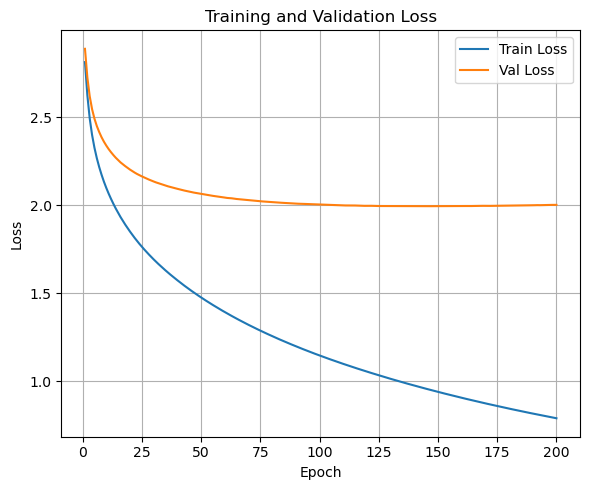

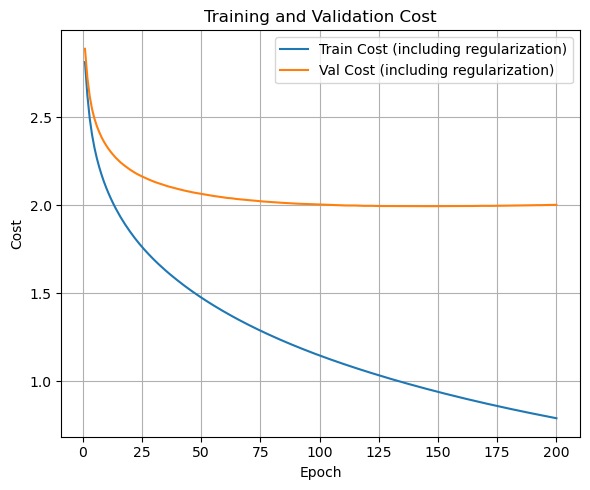

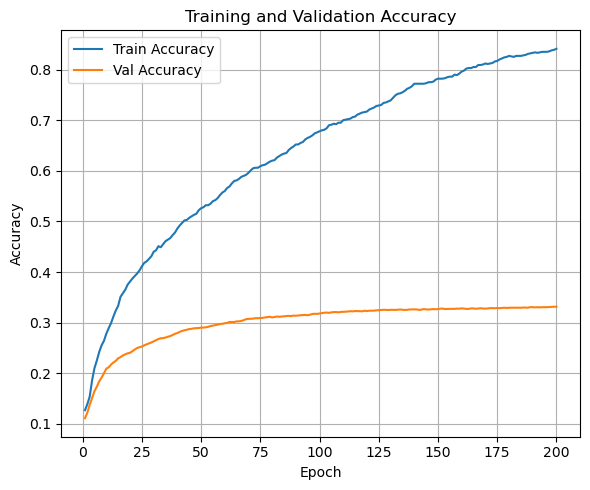

In [17]:
optimizer.plot_training_progress()

## Cyclical learning rate

In [2]:
model = Model(32*32*3, 50, 10)
optimizer = Optimizer(model, CrossEntropyLoss(), lr=0.0, reg=0.01)
scaler = Scaler()
X_train, Y_train, y_train = load_batch("data_batch_1")
X_val, Y_val, y_val = load_batch("data_batch_2")
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

/home/josef/Uni/P4/deep_learning/DD2424-assignments/assignment2/src/utils.py:20: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  dict = pickle.load(fo, encoding='bytes')


In [3]:
optimizer.train_with_cyclical_lr(X_train, y_train, X_val, y_val, lr_min = 1e-5, lr_max = 1e-1, step_size=500, n_cycles=1, batch_size=100, print_every=100)

Update step 100 - Train Loss: 2.9521, Val Loss: 2.9319, Train Acc: 0.1123, Val Acc: 0.1169, LR: 0.019808
Update step 200 - Train Loss: 1.8412, Val Loss: 1.9585, Train Acc: 0.3474, Val Acc: 0.3136, LR: 0.039806
Update step 300 - Train Loss: 1.7107, Val Loss: 1.9126, Train Acc: 0.4051, Val Acc: 0.3528, LR: 0.059804
Update step 400 - Train Loss: 1.5689, Val Loss: 1.8096, Train Acc: 0.4474, Val Acc: 0.3775, LR: 0.079802
Update step 500 - Train Loss: 1.4929, Val Loss: 1.7347, Train Acc: 0.4816, Val Acc: 0.4027, LR: 0.099800
Update step 600 - Train Loss: 1.5490, Val Loss: 1.7941, Train Acc: 0.4446, Val Acc: 0.3707, LR: 0.080202
Update step 700 - Train Loss: 1.4411, Val Loss: 1.7064, Train Acc: 0.4882, Val Acc: 0.4015, LR: 0.060204
Update step 800 - Train Loss: 1.3168, Val Loss: 1.6218, Train Acc: 0.5452, Val Acc: 0.4317, LR: 0.040206
Update step 900 - Train Loss: 1.2419, Val Loss: 1.5865, Train Acc: 0.5815, Val Acc: 0.4480, LR: 0.020208
Update step 1000 - Train Loss: 1.2015, Val Loss: 1.5715

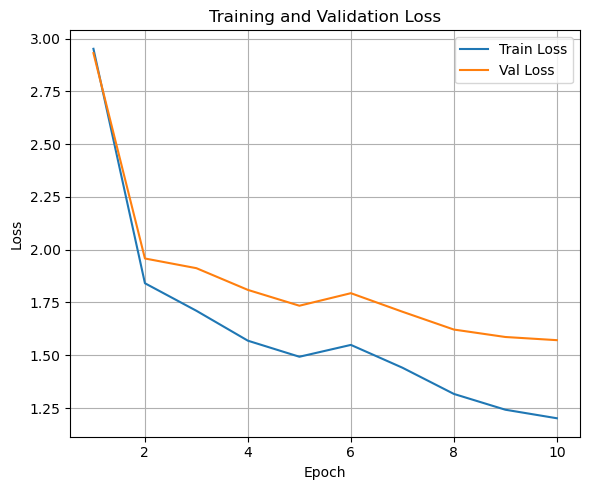

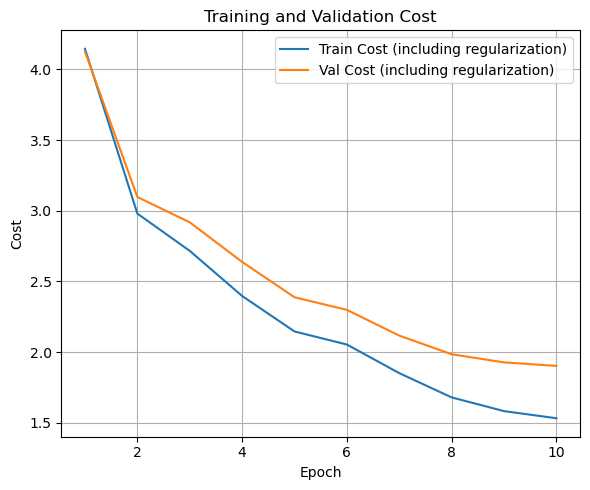

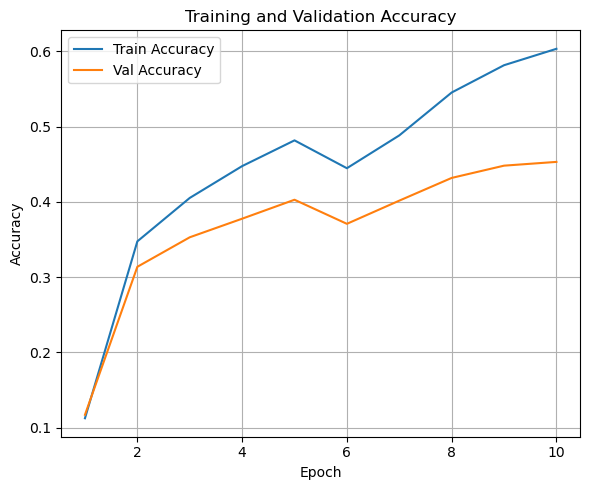

In [4]:
optimizer.plot_training_progress()

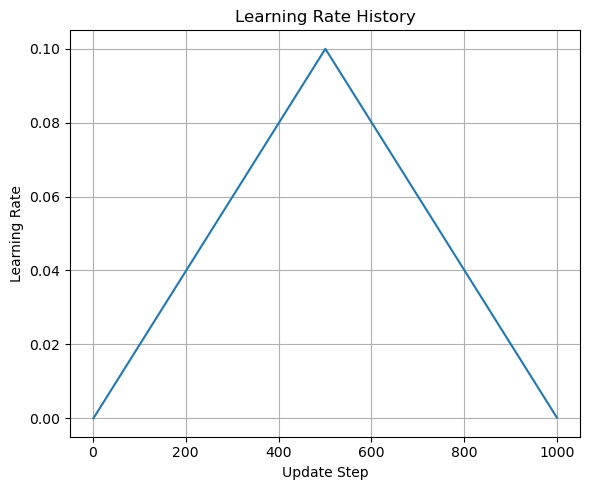

In [ ]:
optimizer.plot_learning_rate_history()

In [22]:
print(optimizer.lr_history)

[1e-05, 0.00020998000000000002, 0.00040996000000000007, 0.0006099400000000001, 0.0008099200000000001, 0.0010099000000000002, 0.0012098800000000002, 0.0014098600000000002, 0.0016098400000000002, 0.00180982, 0.0020098000000000004, 0.00220978, 0.0024097600000000004, 0.00260974, 0.0028097200000000004, 0.0030097, 0.0032096800000000003, 0.0034096600000000006, 0.00360964, 0.00380962, 0.0040096, 0.00420958, 0.00440956, 0.00460954, 0.00480952, 0.0050095, 0.00520948, 0.00540946, 0.00560944, 0.00580942, 0.0060094, 0.0062093800000000005, 0.00640936, 0.006609340000000001, 0.006809320000000001, 0.007009300000000001, 0.007209279999999999, 0.00740926, 0.00760924, 0.00780922, 0.008009200000000001, 0.00820918, 0.00840916, 0.00860914, 0.00880912, 0.0090091, 0.00920908, 0.00940906, 0.009609040000000001, 0.009809020000000002, 0.010009, 0.01020898, 0.01040896, 0.01060894, 0.01080892, 0.0110089, 0.011208880000000001, 0.011408860000000002, 0.01160884, 0.01180882, 0.0120088, 0.01220878, 0.012408760000000001, 0

In [12]:
model = Model(32*32*3, 50, 10)
optimizer = Optimizer(model, CrossEntropyLoss(), lr=0.0, reg=0.01)
scaler = Scaler()
X_train, Y_train, y_train = load_batch("data_batch_1")
X_val, Y_val, y_val = load_batch("data_batch_2")
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

In [10]:
optimizer.train_with_cyclical_lr(X_train, y_train, X_val, y_val, lr_min = 1e-5, lr_max = 1e-1, step_size=500, n_cycles=3, batch_size=100, print_every=500)

Update step 500 - Train Loss: 1.5087, Val Loss: 1.7011, Train Acc: 0.4757, Val Acc: 0.4044, LR: 0.099800
Update step 1000 - Train Loss: 1.3372, Val Loss: 1.5798, Train Acc: 0.5579, Val Acc: 0.4503, LR: 0.000210
Update step 1500 - Train Loss: 1.3789, Val Loss: 1.6289, Train Acc: 0.5226, Val Acc: 0.4299, LR: 0.099800
Update step 2000 - Train Loss: 1.2734, Val Loss: 1.5495, Train Acc: 0.5774, Val Acc: 0.4620, LR: 0.000210
Update step 2500 - Train Loss: 1.3521, Val Loss: 1.6054, Train Acc: 0.5420, Val Acc: 0.4356, LR: 0.099800
Update step 3000 - Train Loss: 1.2498, Val Loss: 1.5418, Train Acc: 0.5862, Val Acc: 0.4596, LR: 0.000210


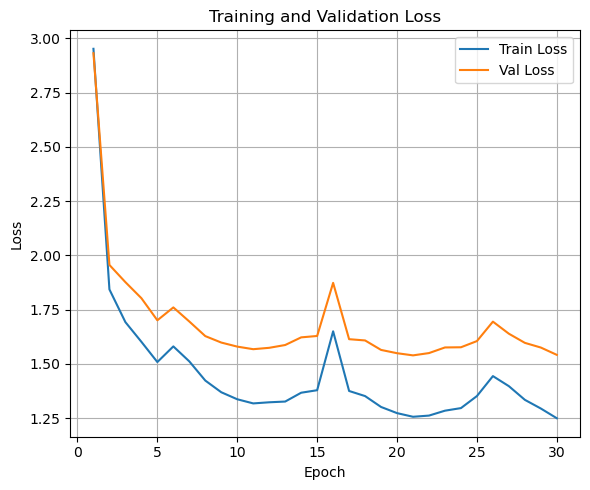

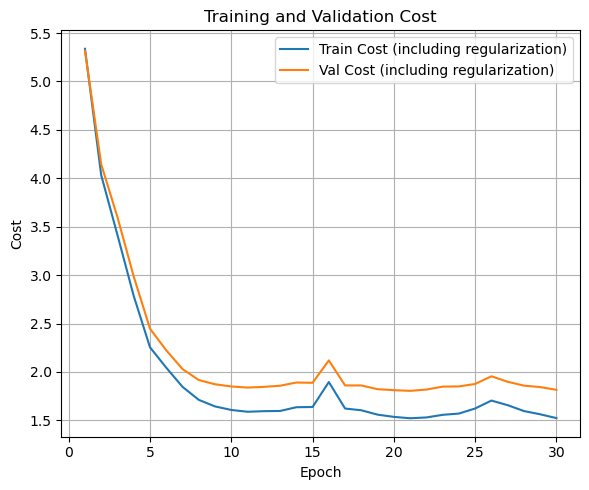

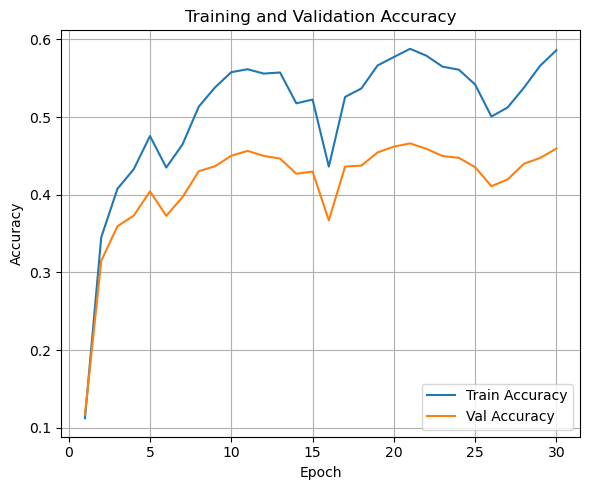

In [11]:
optimizer.plot_training_progress()

## Excercise 4

In [ ]:
model = Model(32*32*3, 50, 10)
optimizer = Optimizer(model, CrossEntropyLoss(), lr=0.0, reg=0.01)
scaler = Scaler()
X_train, Y_train, y_train = load_batch("data_batch_1")
X_val, Y_val, y_val = load_batch("data_batch_2")
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)